# Checking the Dispersion-Bias Note by Simulation- FactorLab Refactor Implementation
## Slides follow Jacob Lan's Example
### Equation (6), Part (ii): estimated-direction error = floor + weight × rotation (as $p \to \infty$)

$$\sin^2\angle(h_j,\,\bar b_j)\;\longrightarrow\;
\underbrace{\frac{\delta^2}{n\rho_j + \delta^2}}_{\text{floor}}
\;+\;
\underbrace{\frac{n\rho_j}{n\rho_j + \delta^2}}_{\text{weight}}\cdot
\underbrace{\sin^2\angle(\hat w_j,\,e_j)}_{\text{rotation}}$$

The note claims the error between an estimated loading direction and the truth splits into
two pieces: a large **floor** you can estimate from data, plus a small, latent **rotation** —
with the split becoming exact as the number of assets $p$ grows.

This deck builds the factor model, simulates returns over a sweep of ambient dimensions,
and tests that claim through the `factor_lab` experiment engine
(`ModelSpec` + `DesignSpec` + `DispersionBiasExperiment`).

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from loguru import logger
logger.remove()  # keep the slides quiet

import numpy as np
import matplotlib.pyplot as plt

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from sim_theorem_partii import DispersionBiasExperiment

OUT_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR.mkdir(exist_ok=True)

# Same canonical diagonal-Gram model as theorem_partii_clean_heavy_tail.ipynb.
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 1.0},   # market-like factor
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
design = DesignSpec(
    n_values=[60],
    p_values=[200, 500, 1000, 2000, 5000, 10000, 20000],
    n_reps=300,
    random_seed=20260511,
    sampling="nested",
    # Heavy-tail variant: swap in student-t samplers, e.g.
    # factor_return_sampler={"distribution": "student_t", "df": 3, "loc": 0.0, "scale": 1.0},
    # idio_return_sampler={"distribution": "student_t", "df": 4, "loc": 0.0, "scale": 1.0},
)

df = run_experiment(model, design, DispersionBiasExperiment())

# Everything below is plotted as angles, to match the rotation_check deck.
def to_deg(v):
    """sin^2 of an angle -> the angle in degrees."""
    return np.degrees(np.arcsin(np.sqrt(np.clip(v, 0.0, 1.0))))

d = df.assign(ang_obs=to_deg(df["sin2_j"]), ang_pred=to_deg(df["rhs"]),
              ang_floor=to_deg(df["floor"]))
avg = d.groupby(["p", "j"])[["ang_obs", "ang_pred", "ang_floor"]].mean().reset_index()
P_VALUES = sorted(d["p"].unique())

NAVY, RED, GRAY = "#1f3864", "#c0392b", "#555555"
FACTOR_COLORS = ["tab:blue", "tab:orange", "tab:green"]
DEG_TICKS = ([0, 30, 60, 90], ["0\u00b0", "30\u00b0", "60\u00b0", "90\u00b0"])
print(f"rows: {len(df)}   p sweep: {P_VALUES}")

replicate: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:09<00:00, 31.05rep/s]

rows: 6300   p sweep: [np.int64(200), np.int64(500), np.int64(1000), np.int64(2000), np.int64(5000), np.int64(10000), np.int64(20000)]


## The theorem holds  (error as an average angle)

### Average misalignment angle over many draws: angle each draw, then average

**Simulation parameters**

- Loadings: $\beta_1 \sim \mathcal N(1,\,1)$, $\;\beta_2 \sim \mathcal N(0,\,1)$, $\;\beta_3 \sim \mathcal N(0,\,1)$
- Factor returns: $f_j \sim \mathcal N(0,\,\sigma_j^2)$, mean 0, annualized vol $\sigma = (16\%,\ 8\%,\ 6\%)$
- Idiosyncratic noise: $z_i \sim \mathcal N(0,\,\delta^2)$, mean 0, annualized vol $\delta = 40\%$
- $n = 60$ periods fixed; $\;p$ swept $200 \to 20{,}000$; $\;40$ replications per $p$ (nested sampling)

![theorem holds](nb_outputs/slide_partii_theorem_holds.png)

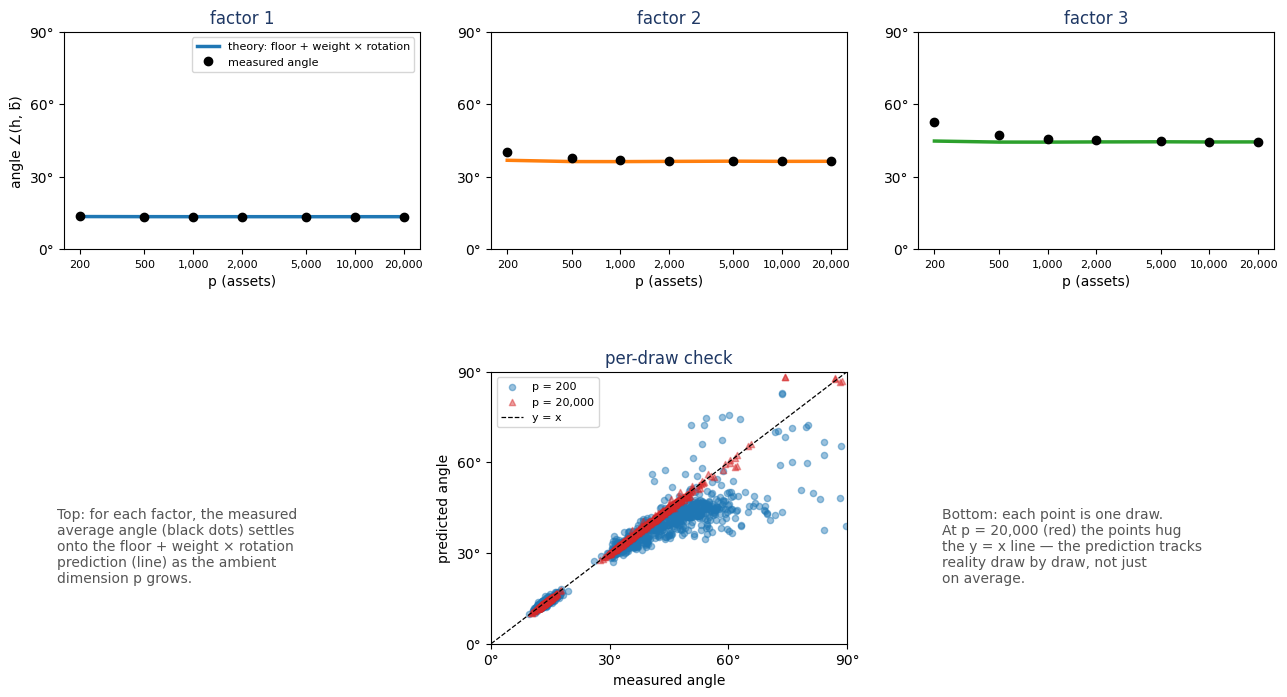

In [2]:
fig = plt.figure(figsize=(13.3, 7.2))
gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.25], hspace=0.5,
                      left=0.06, right=0.97, top=0.93, bottom=0.08)

for j in (1, 2, 3):
    ax = fig.add_subplot(gs[0, j - 1])
    a = avg[avg["j"] == j]
    ax.plot(a["p"], a["ang_pred"], color=FACTOR_COLORS[j - 1], lw=2.5,
            label="theory: floor + weight \u00d7 rotation")
    ax.plot(a["p"], a["ang_obs"], "ko", ms=6, label="measured angle")
    ax.set_xscale("log")
    ax.set_xticks(P_VALUES, [f"{p:,}" for p in P_VALUES], fontsize=8)
    ax.set_xticks([], minor=True)
    ax.set_ylim(0, 90)
    ax.set_yticks(*DEG_TICKS)
    ax.set_title(f"factor {j}", color=NAVY)
    ax.set_xlabel("p (assets)")
    if j == 1:
        ax.set_ylabel("angle \u2220(h, b\u0304)")
        ax.legend(fontsize=8, loc="upper right")

p_lo, p_hi = P_VALUES[0], P_VALUES[-1]
ax_sc = fig.add_subplot(gs[1, 1])
for p_sel, color, marker in [(p_lo, "tab:blue", "o"), (p_hi, "tab:red", "^")]:
    s = d[d["p"] == p_sel]
    ax_sc.scatter(s["ang_obs"], s["ang_pred"], s=20, c=color, marker=marker,
                  alpha=0.45, label=f"p = {p_sel:,}")
ax_sc.plot([0, 90], [0, 90], "k--", lw=0.9, label="y = x")
ax_sc.set_xlim(0, 90); ax_sc.set_ylim(0, 90)
ax_sc.set_xticks(*DEG_TICKS); ax_sc.set_yticks(*DEG_TICKS)
ax_sc.set_xlabel("measured angle"); ax_sc.set_ylabel("predicted angle")
ax_sc.set_title("per-draw check", color=NAVY)
ax_sc.legend(fontsize=8, loc="upper left")

fig.text(0.055, 0.27,
         "Top: for each factor, the measured\n"
         "average angle (black dots) settles\n"
         "onto the floor + weight \u00d7 rotation\n"
         "prediction (line) as the ambient\n"
         "dimension p grows.",
         fontsize=10, color=GRAY, va="top")
fig.text(0.72, 0.27,
         "Bottom: each point is one draw.\n"
         f"At p = {p_hi:,} (red) the points hug\n"
         "the y = x line \u2014 the prediction tracks\n"
         "reality draw by draw, not just\n"
         "on average.",
         fontsize=10, color=GRAY, va="top")

fig.savefig(OUT_DIR / "slide_partii_theorem_holds.png", dpi=150, bbox_inches="tight")
plt.show()

## What the check reveals

### The floor is large and estimable; the rotation is small and latent

![what the check reveals](nb_outputs/slide_partii_check_reveals.png)

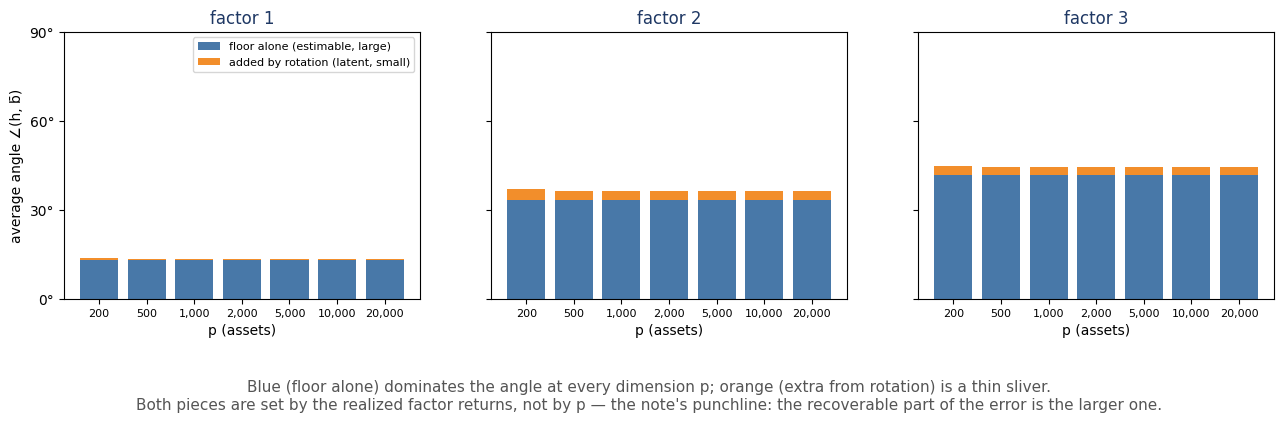

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13.3, 4.6), sharey=True)
fig.subplots_adjust(left=0.06, right=0.97, top=0.86, bottom=0.28)

x = np.arange(len(P_VALUES))
for j, ax in zip((1, 2, 3), axes):
    a = avg[avg["j"] == j].set_index("p").loc[P_VALUES]
    floor_part = a["ang_floor"].to_numpy()
    rotation_part = a["ang_pred"].to_numpy() - floor_part
    ax.bar(x, floor_part, color="#4878a8", label="floor alone (estimable, large)")
    ax.bar(x, rotation_part, bottom=floor_part, color="#f28e2b",
           label="added by rotation (latent, small)")
    ax.set_xticks(x, [f"{p:,}" for p in P_VALUES], fontsize=8)
    ax.set_ylim(0, 90)
    ax.set_yticks(*DEG_TICKS)
    ax.set_title(f"factor {j}", color=NAVY)
    ax.set_xlabel("p (assets)")
axes[0].set_ylabel("average angle \u2220(h, b\u0304)")
axes[0].legend(fontsize=8, loc="upper right")

fig.text(0.5, 0.04,
         "Blue (floor alone) dominates the angle at every dimension p; orange (extra from "
         "rotation) is a thin sliver.\nBoth pieces are set by the realized factor returns, "
         "not by p \u2014 the note's punchline: the recoverable part of the error is the larger one.",
         fontsize=11, color=GRAY, ha="center")

fig.savefig(OUT_DIR / "slide_partii_check_reveals.png", dpi=150, bbox_inches="tight")
plt.show()

## The components up close

### Floor and rotation are p-stable; the formula becomes exact as $p \to \infty$

![floor and rotation components](nb_outputs/slide_partii_components.png)

In [4]:
import matplotlib
_backend = matplotlib.get_backend()
from fl_graphics import plot_components   # module import switches to Agg
matplotlib.use(_backend)                   # keep inline display working

plot_components(df, OUT_DIR / "slide_partii_components.png", n_show=60)

## Presenting this notebook

Live, in JupyterLab (`jupyterlab-rise`): click **Render with RISE** in the toolbar (Alt+R).

Code cells are marked `skip`, so the presentation shows only markdown; the figures are
embedded as markdown images pointing at `nb_outputs/slide_partii_*.png`, which the code
cells regenerate on each run. Changed the model or design? Run All Cells, then present.

Static export:

```bash
jupyter nbconvert --to slides theorem_partii_slides.ipynb --no-input
```

For the heavy-tailed variant, swap the commented `student_t` samplers into the
`DesignSpec` in the setup cell and re-run.